## Initial LLM Optimization

An initial agentic optimization run was performed for both conditions: **with biological information** and **without biological information**. The experiment budget was limited to **3 iterations** to verify that the workflow, LLM decision-making, validation, experiment logging, and final parameter selection operate as intended. A larger exploration budget will be investigated once the workflow has been further established. The updated workflow also reduces hardcoded optimization decisions and allows the LLM to perform the main reasoning through prompts, using established scRNA-seq evidence such as marker genes where applicable.

### Biology-guided optimization

* **Experiments:** 3 iterations
* **Runtime:** ~98.9 seconds
* **LLM seed:** 3
* **Marker genes:** Top 5 marker genes per cluster
* **Selected parameters:** `n_neighbors = 15`, `resolution = 1.0`, `n_pcs = 20`
* **Selected iteration:** 0
* The LLM considered intrinsic clustering metrics, cluster structure, and marker-gene information when proposing and selecting configurations.
* Iteration 1 achieved slightly stronger intrinsic metrics, but Iteration 0 was selected because it uniquely resolved a coherent interferon-stimulated gene (ISG) cluster (`ISG15`, `IFI6`, `MX1`, `IFIT1`, `OAS1`) while maintaining biologically coherent PBMC populations.
* The final selection therefore favored the configuration with the strongest overall combination of intrinsic metrics, cluster structure, and biological coherence.
* **Note:** The current experiment uses 5 marker genes per cluster. The effect of providing **10 marker genes per cluster** will be investigated in a subsequent experiment.

### No-biology optimization

* **Experiments:** 3 iterations
* **Runtime:** ~75.2 seconds
* **Selected parameters:** `n_neighbors = 30`, `resolution = 0.8`, `n_pcs = 20`
* **Selected iteration:** 2
* The LLM relied on intrinsic clustering metrics and cluster structure without using marker-gene information.
* The final selection favored the configuration with the strongest overall intrinsic clustering evidence and a reasonable cluster structure.



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)


True

In [3]:
from src import data_load as dl
from src import preprocessing_pipeline as prp
from src import clustering as cl
from src import new_evaluation as ev
from src import optimization as opt
from src import visualisation as viz
from src import marker as mk
from src.graph import graph
import src.openAI_llm as lm
from src.agent import cluster_node, evaluate_node, reflection_node, final_selection_node
from src.decision import (OptimizationDecision, FinalExperimentSelection,)
from src.wt_biology_prompts import (build_reflection_prompt, build_final_selection_prompt,)
from src.experiment_logger import (create_experiment_log,save_experiment_log,add_final_result,)

import scanpy as sc
import pandas as pd
from langchain_openai.chat_models import ChatOpenAI 
from IPython.display import Image, display

In [4]:
# Stability analysis

from src.stability import run_stability_analysis, calculate_pairwise_ari, calculate_cluster_jaccard
import numpy as np
from collections import defaultdict
from collections import Counter

### Create the LLM (OPENAI)

In [5]:
llm = ChatOpenAI(model="gpt-5", temperature=0,)

## Fixed Preprocessing Pipeline

In [6]:
pbmc_data = dl.load_pbmc3k()
pbmc_data = prp.run_preprocessing_pipeline(pbmc_data)

Running QC...
Running normalization...
Running PCA...
Finished preprocessing.


In [7]:
pbmc_data.var["highly_variable"].sum()

np.int64(2000)

In [8]:
pbmc_data

AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'scaled'

## Agent State Setup
The state acts as the agent's shared memory. Technically, LangGraph simply gives every node the same shared memory. Each node:

+ reads what it needs
+ updates what changed
+ returns the updated state

In this setup, it stores the dataset, current parameters, evaluation metrics, experiment history, and optimization progress, allowing each node in the LangGraph workflow to access the information it needs and update it as the optimization proceeds.


In [9]:
experiment_log = create_experiment_log(
    experiment_id="EXP-029e",
    dataset="PBMC3K",
    method="agentic_biology",
    condition="biology",
    agent_version="v0.6-reproducibility",
    llm_seed=lm.LLM_SEED,
    change=(
        "Added reproducibility controls for agentic parameter exploration, "
        "including controlled LLM decision validation, duplicate "
        "configuration checks, and a maximum experiment budget."
    ),
    reason_for_change=(
        "To enable a controlled assessment of the reproducibility of "
        "agentic parameter exploration by validating LLM-proposed decisions, "
        "preventing repeated configurations, and limiting the number of "
        "clustering evaluations per run."
    ),
)

In [10]:
state = {
    "messages": [],

    "adata": pbmc_data,

    "parameters": {
        "n_neighbors": 15,
        "resolution": 1.0,
        "n_pcs": 20,
    },

    # Experimental condition
    "condition": "biology",

    "metrics": {},

    "history": [],

    "experiment_log": experiment_log,

    "iteration": 0,

    "decision": "continue",

    "reason": "",

    "evaluated_configs": [],

    "clustering_time": 0.0,

    "evaluation_time": 0.0,

    "llm_decision_time": 0.0,

    # Final selection fields
    "selected_iteration": None,

    "best_experiment": None,

    "final_selection_reason": None,

    "final_selection_time": 0.0,
}

In [11]:
print(pbmc_data.obsm["X_pca"].shape)

(2638, 50)


### Run Agentic Optimization

The following cell executes the agentic optimization workflow using the specified initial state and saves the resulting experiment log.

The agent will iteratively:
- run clustering,
- evaluate the clustering,
- request an LLM reflection/parameter decision,
- continue until the exploration budget is reached or the LLM decides to stop,
- and finally select the preferred experiment from the completed history.


In [12]:
result = graph.invoke(state)

save_experiment_log(result["experiment_log"])


CURRENT EVALUATION
Clusters: 10
Silhouette: 0.0748
DBI: 2.6664
WC-dispersion: 374182.5000
Banfield-Raftery: 12939.8262

LLM PROMPT

You are an expert in single-cell RNA-seq clustering optimization.

Your objective is to explore clustering parameters and identify
parameter configurations that provide strong overall clustering
evidence while avoiding unnecessary over-fragmentation or
under-clustering.

The optimization should balance potential improvement against the
cost of additional experiments. Do not continue exploring merely for
the sake of using the available experiment budget.

BIOLOGY-INFORMED EXPERIMENTAL CONDITION:

This is the biology-informed experimental condition.

* Use intrinsic clustering metrics, cluster-structure information,
  and biological evidence provided in the prompt when making
  optimization decisions.

* Biological evidence may be used to assess whether clusters appear
  biologically coherent, whether potentially distinct populations may
  have been merged,

PosixPath('experiments/EXP-029e.json')

In [13]:
# print(graph.get_graph().draw_mermaid())

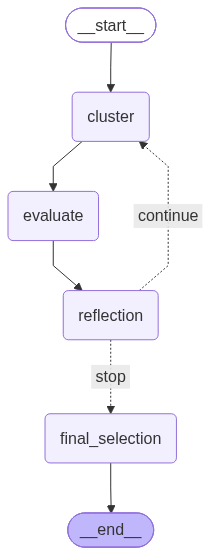

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
print("Decision:", result["decision"])
print("Reason:", result["reason"])

Decision: stop
Reason: Maximum number of experiments (3) reached.


In [16]:
state.keys()

dict_keys(['messages', 'adata', 'parameters', 'condition', 'metrics', 'history', 'experiment_log', 'iteration', 'decision', 'reason', 'evaluated_configs', 'clustering_time', 'evaluation_time', 'llm_decision_time', 'selected_iteration', 'best_experiment', 'final_selection_reason', 'final_selection_time'])

In [17]:
# print(type(decision))

In [ ]:
for experiment in result["history"]:
    print("\nIteration:", experiment["iteration"])
    print("Parameters:", experiment["parameters"])
    print("Metrics:", experiment["metrics"])

In [19]:
# print(decision)

In [28]:
best_experiment = result["best_experiment"]

best_params = best_experiment["parameters"]

{'n_neighbors': 15, 'resolution': 1.0, 'n_pcs': 20}


In [ ]:
print("Selected iteration:", result["selected_iteration"])
print("Selected parameters:", best_params)

In [29]:
pbmc_data_best = cl.run_clustering(
    pbmc_data.copy(),
    n_neighbors=best_params["n_neighbors"],
    resolution=best_params["resolution"],
    n_pcs=best_params["n_pcs"],)

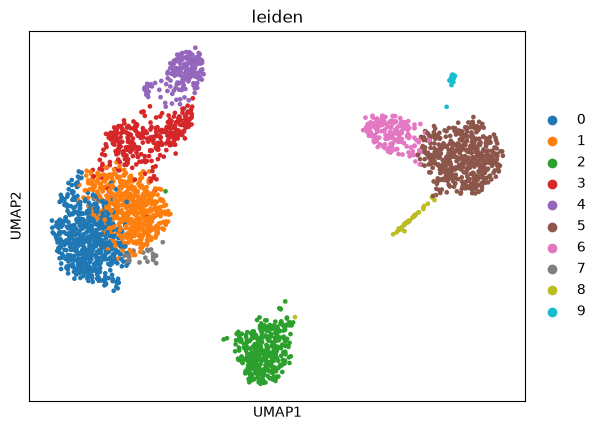

In [30]:
viz.plot_umap(pbmc_data_best, color="leiden")

In [31]:
ev.get_cluster_summary(pbmc_data_best)

{'0': 574,
 '1': 552,
 '2': 347,
 '3': 299,
 '4': 164,
 '5': 465,
 '6': 168,
 '7': 23,
 '8': 32,
 '9': 14}